# Step 1: Create Universe and Returns
This notebook loads the historical Yahoo Finance data and calculates the tradable universe based on Average Daily Volume (ADV) constraints, as well as the daily returns.

In [1]:
import pandas as pd
import os

DATA_DIR = "stores"
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('top_5000_yf_data.pkl')
print('Data loaded successfully.')

Loading top_5000_yf_data.pkl...
Data loaded successfully.


In [3]:
# Calculate Average Daily Volume (ADV) for trailing 60 days
# The user guide specifies a 5M USD 3-month ADV filter (we use 60 trading days)
# ADV = Volume * Close Price
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=1).mean()

Universe shape: (4112, 5002)


<Axes: title={'center': 'Number of Tradable Stocks Over Time (ADV > $5M)'}, xlabel='Date'>

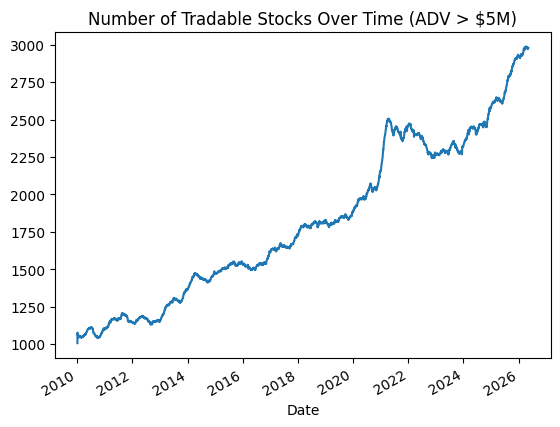

In [4]:
# Creating 5M+ Average Daily Volume Universe
df_universe_5m = (df_adv_60 > 5_000_000).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time (ADV > $5M)")

In [6]:
# Saving 5M universe to stores folder
# Drop any duplicated columns
df_universe_5m = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]
df_universe_5m.to_parquet(os.path.join(DATA_DIR, 'universe_5m.parquet'), engine='pyarrow')
print('Saved universe_5m.parquet')

Saved universe_5m.parquet


In [7]:
# Calculating returns for each ticker every day
# Using Adj Close to account for dividends and stock splits
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)

In [8]:
# Saving returns to parquet file
# Drop any duplicated columns
returns = returns.loc[:, ~returns.columns.duplicated()]
returns.to_parquet(os.path.join(DATA_DIR, 'returns.parquet'), engine='pyarrow')
print('Saved returns.parquet')

Saved returns.parquet
